# Customer Clustering – K-Means & DBSCAN

Starting from the EDA dataset, we build a feature matrix, apply two clustering algorithms  
(**K-Means** and **DBSCAN**), evaluate results and profile each cluster.

**Sections:**
1. Setup & Data Loading
2. Feature Engineering
3. Preprocessing & Dimensionality Reduction (PCA)
4. K-Means – Elbow + Silhouette, Fit, Profile
5. DBSCAN – Parameter Search, Fit, Profile
6. Cluster Comparison & Business Interpretation

---
## 1. Setup & Data Loading

In [6]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

RANDOM_STATE = 42
M_COLS = [f'M-{i}' for i in range(35, -1, -1)]   # M-35 (oldest) -> M-0 (newest)

print('Libraries loaded OK')

Libraries loaded OK


In [7]:
BASE_DIR   = os.getcwd()
input_path = os.path.join(BASE_DIR, 'source', 'dataset_eda.csv')

df = pd.read_csv(input_path)
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Dataset: 16,791 rows x 43 columns


,NACE,NACE_Desc,Revenue,Employees,Province,City,Region,M-35,M-34,M-33,...,M-9,M-8,M-7,M-6,M-5,M-4,M-3,M-2,M-1,M-0
0,47.71,Retail sale of clothing in specialised stores,93840,2,PA,Palermo,Sicilia,80,718,3888,...,65919,58362,69779,62338,71332,54796,91169,104473,127672,139105
1,49.41,Freight transport by road,1242280,4,MB,Monza,Lombardia,44520,43793,54545,...,78015,73822,83936,68864,107911,37607,100365,105866,84089,95330
2,47.91,Retail sale via mail order houses or via Internet,44451177,159,MI,Milano,Lombardia,65703,87812,65768,...,35367,41628,60515,57786,85252,76067,86415,75573,101941,237050


---
## 2. Feature Engineering

We derive a compact set of descriptive features from the raw columns:

| Feature | Description |
|---|---|
| `log_revenue` | log1p(Revenue) – company size proxy |
| `log_employees` | log1p(Employees) – company size proxy |
| `log_total_vol` | log1p(sum of all M columns) – overall activity |
| `log_recent_vol` | log1p(sum of M-0 to M-5) – last 6 months activity |
| `log_old_vol` | log1p(sum of M-35 to M-30) – first 6 months activity |
| `volume_trend` | recent_vol / (old_vol + 1) – growth direction |
| `vol_cv` | Coefficient of Variation of monthly volumes – regularity |
| `active_months` | Number of months with volume > 0 – engagement breadth |
| `peak_month_share` | max monthly vol / total vol – concentration |
| `recency_score` | share of total volume in the last 12 months |

In [8]:
df_feat = df.copy()

# --- Size proxies ---
df_feat['log_revenue']   = np.log1p(df_feat['Revenue'])
df_feat['log_employees'] = np.log1p(df_feat['Employees'])

# --- Volume aggregates ---
recent_cols = [f'M-{i}' for i in range(6)]          # M-0..M-5  (last 6 months)
old_cols    = [f'M-{i}' for i in range(35, 29, -1)] # M-35..M-30 (first 6 months)
last12_cols = [f'M-{i}' for i in range(12)]         # M-0..M-11

total_vol  = df_feat[M_COLS].sum(axis=1)
recent_vol = df_feat[recent_cols].sum(axis=1)
old_vol    = df_feat[old_cols].sum(axis=1)
last12_vol = df_feat[last12_cols].sum(axis=1)

df_feat['log_total_vol']  = np.log1p(total_vol)
df_feat['log_recent_vol'] = np.log1p(recent_vol)
df_feat['log_old_vol']    = np.log1p(old_vol)

# --- Trend: ratio recent / old ---
df_feat['volume_trend'] = recent_vol / (old_vol + 1)
# Cap extreme values at 99th percentile
trend_cap = df_feat['volume_trend'].quantile(0.99)
df_feat['volume_trend'] = df_feat['volume_trend'].clip(upper=trend_cap)

# --- Regularity: Coefficient of Variation ---
monthly_matrix = df_feat[M_COLS].values.astype(float)
monthly_mean   = monthly_matrix.mean(axis=1)
monthly_std    = monthly_matrix.std(axis=1)
df_feat['vol_cv'] = np.where(monthly_mean > 0, monthly_std / monthly_mean, 0)

# --- Active months ---
df_feat['active_months'] = (monthly_matrix > 0).sum(axis=1)

# --- Peak concentration ---
df_feat['peak_month_share'] = np.where(
    total_vol > 0,
    monthly_matrix.max(axis=1) / total_vol,
    0
)

# --- Recency score ---
df_feat['recency_score'] = np.where(
    total_vol > 0,
    last12_vol / total_vol,
    0
)

FEATURE_COLS = [
    'log_revenue', 'log_employees',
    'log_total_vol', 'log_recent_vol', 'log_old_vol',
    'volume_trend', 'vol_cv', 'active_months',
    'peak_month_share', 'recency_score'
]

print(f'Feature matrix: {len(FEATURE_COLS)} features')
df_feat[FEATURE_COLS].describe().round(3)

Feature matrix: 10 features


,log_revenue,log_employees,log_total_vol,log_recent_vol,log_old_vol,volume_trend,vol_cv,active_months,peak_month_share,recency_score
count,16791.000,16791.000,16791.000,16791.000,16784.000,16791.000,16791.000,16791.000,16791.000,16791.000
mean,10.817,2.080,6.581,3.416,4.358,125.552,2.402,17.528,0.345,0.274
std,6.330,1.308,2.716,3.418,3.170,718.925,1.926,13.765,0.329,0.307
min,0.000,0.000,0.693,0.000,0.000,-16.417,0.093,1.000,0.032,0.000
25%,9.119,0.693,4.419,0.000,0.000,0.000,0.841,3.000,0.092,0.000
50%,13.546,1.946,6.690,3.045,4.710,0.295,1.759,14.000,0.198,0.227
75%,15.199,2.944,8.619,6.354,6.858,1.432,3.616,34.000,0.500,0.387
max,17.875,9.881,15.421,13.403,15.390,6039.200,36.297,36.000,4.750,1.188


---
## 3. Preprocessing & Dimensionality Reduction (PCA)

In [9]:
X = df_feat[FEATURE_COLS].copy()

# Drop rows with NaN (should be minimal after feature eng)
mask_valid = X.notna().all(axis=1)
X = X[mask_valid].reset_index(drop=True)
df_clean = df_feat[mask_valid].reset_index(drop=True)
print(f'Valid rows: {len(X):,} / {len(df_feat):,}')

# Standardise
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\nScaled feature stats (should be ~0 mean, ~1 std):')
pd.DataFrame(X_scaled, columns=FEATURE_COLS).describe().round(2)

Valid rows: 16,784 / 16,791

Scaled feature stats (should be ~0 mean, ~1 std):


,log_revenue,log_employees,log_total_vol,log_recent_vol,log_old_vol,volume_trend,vol_cv,active_months,peak_month_share,recency_score
count,16784.00,16784.00,16784.00,16784.00,16784.00,16784.00,16784.00,16784.00,16784.00,16784.00
mean,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.71,-1.59,-2.17,-1.00,-1.37,-0.17,-1.21,-1.20,-0.96,-0.89
25%,-0.26,-1.06,-0.80,-1.00,-1.37,-0.17,-0.82,-1.06,-0.77,-0.89
50%,0.43,-0.10,0.04,-0.11,0.11,-0.17,-0.34,-0.26,-0.45,-0.16
75%,0.69,0.66,0.75,0.86,0.79,-0.17,0.64,1.20,0.47,0.37
max,1.11,5.97,3.25,2.92,3.48,8.22,17.22,1.34,8.89,2.98


Components to reach 90% variance: 5


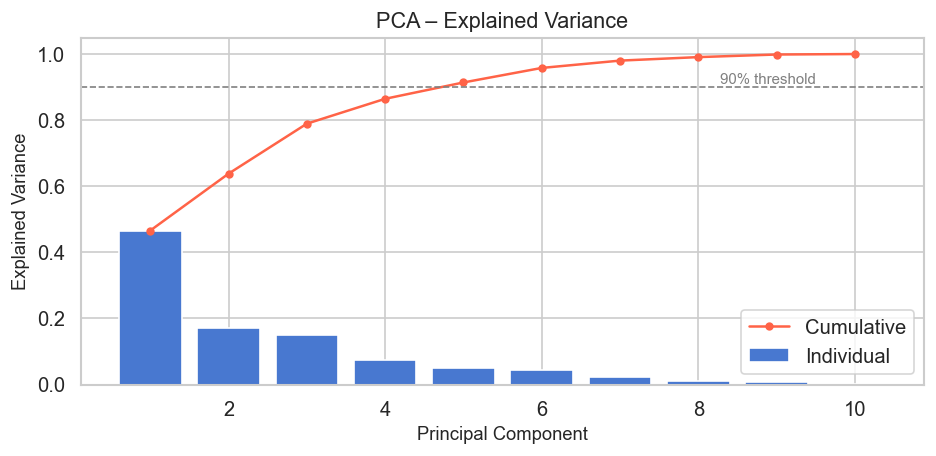

PCA 2D shape: (16784, 2)  |  PCA 5D shape (DBSCAN input, capped at 6): (16784, 5)


In [10]:
# PCA for visualisation (2D) and for DBSCAN input
#
# NOTE – Curse of dimensionality: DBSCAN is very sensitive to high-dimensional
# spaces where distances between points become uniform.  We therefore cap the
# DBSCAN PCA space at DBSCAN_MAX_COMPONENTS even if more components are needed
# to reach the 90% variance threshold.  2D is kept for visual inspection.

DBSCAN_MAX_COMPONENTS = 6   # empirically robust upper limit for DBSCAN

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.argmax(cumvar >= 0.90)) + 1
print(f'Components to reach 90% variance: {n_components_90}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_,
       color=sns.color_palette('muted')[0], edgecolor='white', label='Individual')
ax.plot(range(1, len(cumvar)+1), cumvar, color='tomato',
        marker='o', markersize=4, linewidth=1.5, label='Cumulative')
ax.axhline(0.90, color='grey', linestyle='--', linewidth=1)
ax.text(len(cumvar)-0.5, 0.91, '90% threshold', ha='right', fontsize=9, color='grey')
ax.set(title='PCA – Explained Variance', xlabel='Principal Component', ylabel='Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

# Reduce to 2D for visualisation
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_scaled)

# Reduce for DBSCAN – capped to avoid curse of dimensionality
n_dbscan_components = min(n_components_90, DBSCAN_MAX_COMPONENTS)
pca_nd = PCA(n_components=n_dbscan_components, random_state=RANDOM_STATE)
X_nd   = pca_nd.fit_transform(X_scaled)
print(f'PCA 2D shape: {X_2d.shape}  |  '
      f'PCA {n_dbscan_components}D shape (DBSCAN input, capped at {DBSCAN_MAX_COMPONENTS}): {X_nd.shape}')


---
## 4. K-Means

### 4.1 Elbow + Silhouette to choose K

In [6]:
K_RANGE = range(2, 12)

inertias   = []
silhouettes = []
db_scores  = []
ch_scores  = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                max_iter=500, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000,
                                        random_state=RANDOM_STATE))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    print(f'K={k:2d}  Inertia={km.inertia_:,.0f}  Silhouette={silhouettes[-1]:.3f}  '
          f'DBI={db_scores[-1]:.3f}  CH={ch_scores[-1]:,.0f}')

K= 2  Inertia=110,369  Silhouette=0.320  DBI=1.264  CH=8,739
K= 3  Inertia=93,000  Silhouette=0.337  DBI=1.032  CH=6,752
K= 4  Inertia=76,273  Silhouette=0.271  DBI=1.227  CH=6,715
K= 5  Inertia=65,487  Silhouette=0.285  DBI=1.142  CH=6,556
K= 6  Inertia=56,865  Silhouette=0.301  DBI=1.123  CH=6,549
K= 7  Inertia=51,510  Silhouette=0.298  DBI=1.112  CH=6,315
K= 8  Inertia=47,408  Silhouette=0.303  DBI=1.085  CH=6,088
K= 9  Inertia=44,140  Silhouette=0.276  DBI=1.151  CH=5,876
K=10  Inertia=41,084  Silhouette=0.268  DBI=1.175  CH=5,750
K=11  Inertia=38,613  Silhouette=0.263  DBI=1.173  CH=5,614


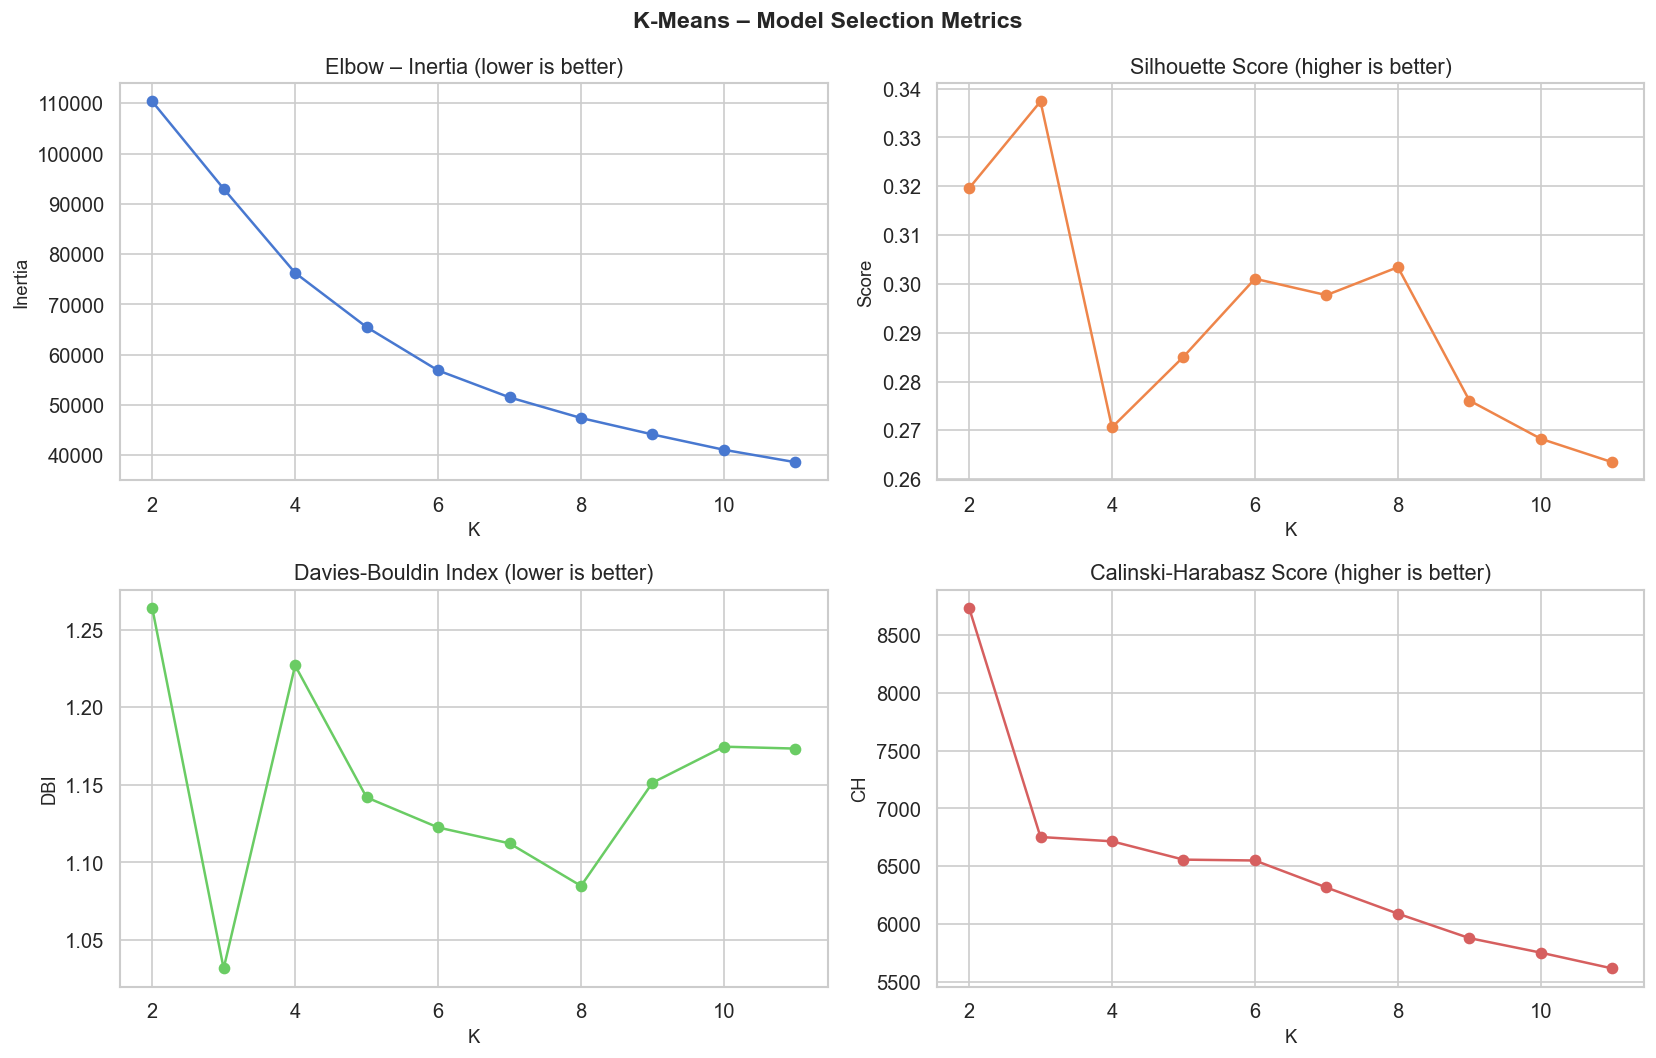

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('K-Means – Model Selection Metrics', fontsize=14, fontweight='bold')
ks = list(K_RANGE)

axes[0,0].plot(ks, inertias, 'o-', color=sns.color_palette('muted')[0])
axes[0,0].set(title='Elbow – Inertia (lower is better)', xlabel='K', ylabel='Inertia')

axes[0,1].plot(ks, silhouettes, 'o-', color=sns.color_palette('muted')[1])
axes[0,1].set(title='Silhouette Score (higher is better)', xlabel='K', ylabel='Score')

axes[1,0].plot(ks, db_scores, 'o-', color=sns.color_palette('muted')[2])
axes[1,0].set(title='Davies-Bouldin Index (lower is better)', xlabel='K', ylabel='DBI')

axes[1,1].plot(ks, ch_scores, 'o-', color=sns.color_palette('muted')[3])
axes[1,1].set(title='Calinski-Harabasz Score (higher is better)', xlabel='K', ylabel='CH')

plt.tight_layout()
plt.show()

### 4.2 Fit final K-Means

Choose K based on the elbow and silhouette plots above.  
**Adjust `BEST_K` if a different value looks more appropriate for the business context.**

In [8]:
# ── Pick K from the elbow / silhouette analysis above ──
BEST_K = silhouettes.index(max(silhouettes)) + K_RANGE.start
print(f'Auto-selected K = {BEST_K}  (highest silhouette)  '
      f'– override manually if needed')

km_final = KMeans(n_clusters=BEST_K, init='k-means++', n_init=50,
                  max_iter=1000, random_state=RANDOM_STATE)
df_clean['km_cluster'] = km_final.fit_predict(X_scaled)

print('\nCluster sizes:')
print(df_clean['km_cluster'].value_counts().sort_index())

Auto-selected K = 3  (highest silhouette)  – override manually if needed

Cluster sizes:
km_cluster
0    8836
1    7582
2     366
Name: count, dtype: int64


In [ ]:
# Compare K-Means choices and validate K=5 against the best silhouette score
comparison_results = []
for k in range(2, 12):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                max_iter=500, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=min(5000, len(labels)), random_state=RANDOM_STATE)
    dbi = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    comparison_results.append({
        'K': k,
        'Silhouette': sil,
        'Davies-Bouldin': dbi,
        'Calinski-Harabasz': ch,
        'Sizes': sizes,
    })

comp_df = pd.DataFrame(comparison_results)
comp_df['Silhouette'] = comp_df['Silhouette'].round(4)
comp_df['Davies-Bouldin'] = comp_df['Davies-Bouldin'].round(4)
comp_df['Calinski-Harabasz'] = comp_df['Calinski-Harabasz'].round(1)

print('K-Means comparison metrics:')
print(comp_df.to_string(index=False))

best_k = int(comp_df.loc[comp_df['Silhouette'].idxmax(), 'K'])
print(f'\nBest K by silhouette: {best_k}')
print('K=5 metrics:')
row5 = comp_df[comp_df['K'] == 5].iloc[0]
print(row5.to_dict())


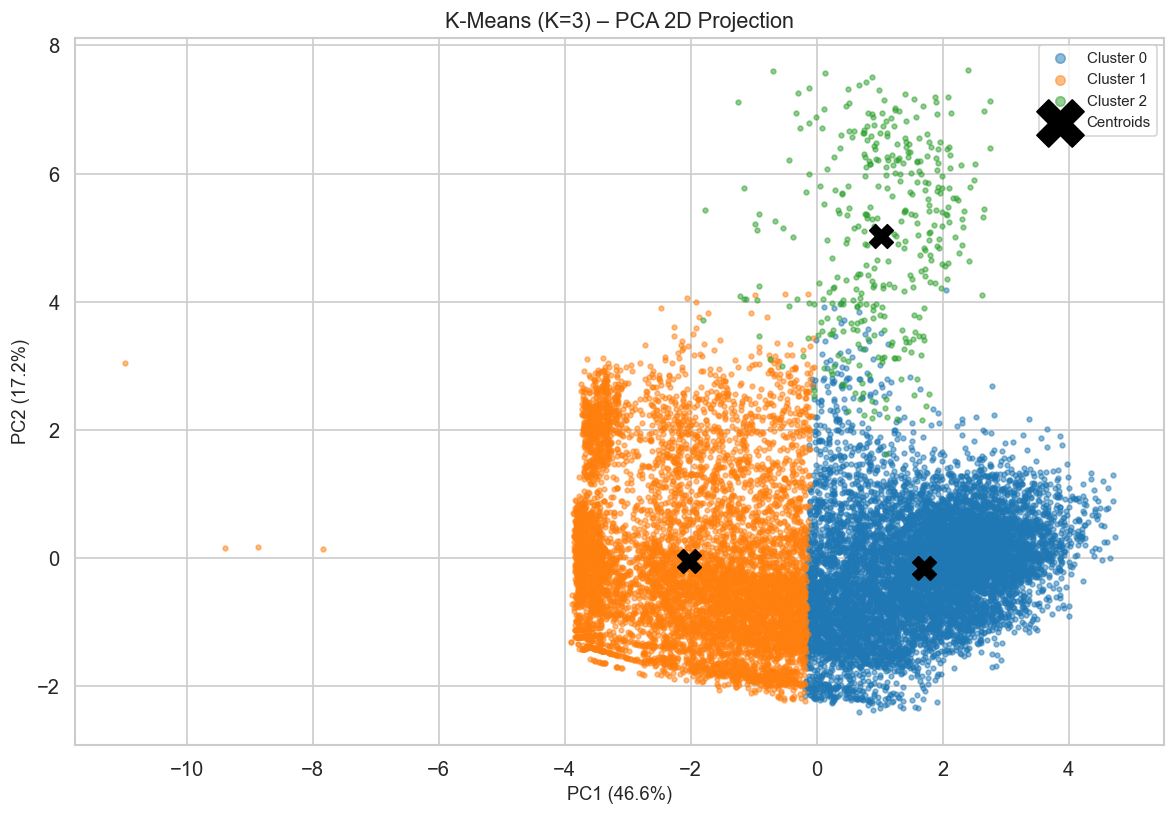

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', BEST_K)

for c in range(BEST_K):
    mask = df_clean['km_cluster'] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=8, alpha=0.5, color=palette[c], label=f'Cluster {c}')

# Plot centroids projected to 2D
centroids_2d = pca2.transform(km_final.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           s=200, marker='X', color='black', zorder=5, label='Centroids')

ax.set(title=f'K-Means (K={BEST_K}) – PCA 2D Projection',
       xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

### 4.3 Cluster Profile

In [10]:
km_profile = (
    df_clean.groupby('km_cluster')[FEATURE_COLS + ['Revenue', 'Employees']]
    .agg(['mean', 'median'])
)
km_profile.columns = ['_'.join(c) for c in km_profile.columns]
km_profile['size'] = df_clean['km_cluster'].value_counts().sort_index()
km_profile['size_pct'] = (km_profile['size'] / len(df_clean) * 100).round(1)
km_profile

,log_revenue_mean,log_revenue_median,log_employees_mean,log_employees_median,log_total_vol_mean,log_total_vol_median,log_recent_vol_mean,log_recent_vol_median,log_old_vol_mean,log_old_vol_median,...,peak_month_share_mean,peak_month_share_median,recency_score_mean,recency_score_median,Revenue_mean,Revenue_median,Employees_mean,Employees_median,size,size_pct
km_cluster,,,,,,,,,,,,,,,,,,,,,
0,10.844622,13.411727,2.040703,1.791759,8.469788,8.334831,5.381697,5.879134,6.447535,6.628041,...,0.119200,0.096905,0.276864,0.289779,4.030092e+06,667788.0,22.890448,5.0,8836,52.6
1,10.764579,13.740178,2.116104,1.945910,4.239593,4.143135,0.863806,0.000000,2.132335,2.079442,...,0.614530,0.542929,0.243804,0.000000,4.637569e+06,927434.0,22.992350,6.0,7582,45.2
2,11.329200,14.235940,2.299380,2.197225,9.525310,9.282458,8.821895,8.631931,0.024190,0.000000,...,0.219179,0.162009,0.842427,0.984129,5.304180e+06,1522616.0,76.407104,8.0,366,2.2


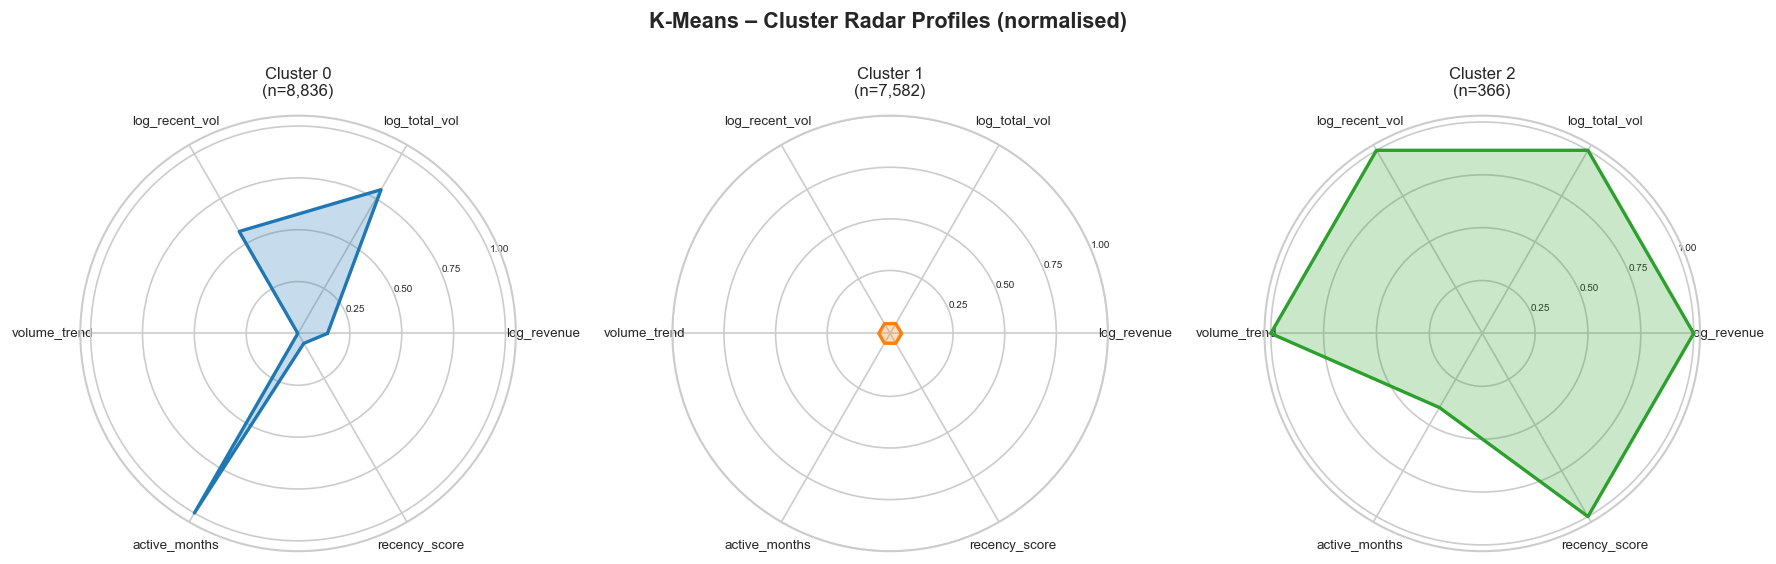

In [11]:
# Radar / spider chart of normalised mean features per cluster
from matplotlib.patches import Patch

radar_features = ['log_revenue', 'log_total_vol', 'log_recent_vol',
                  'volume_trend', 'active_months', 'recency_score']

cluster_means = df_clean.groupby('km_cluster')[radar_features].mean()
# Normalise 0-1 per feature across clusters
norm_means = (cluster_means - cluster_means.min()) / \
             (cluster_means.max() - cluster_means.min() + 1e-9)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, BEST_K, figsize=(5 * BEST_K, 5),
                         subplot_kw=dict(polar=True))
if BEST_K == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    values = norm_means.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=palette[i], linewidth=2)
    ax.fill(angles, values, color=palette[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, fontsize=8)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=6)
    n_clients = df_clean['km_cluster'].value_counts()[i]
    ax.set_title(f'Cluster {i}\n(n={n_clients:,})', fontsize=10, pad=12)

fig.suptitle('K-Means – Cluster Radar Profiles (normalised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

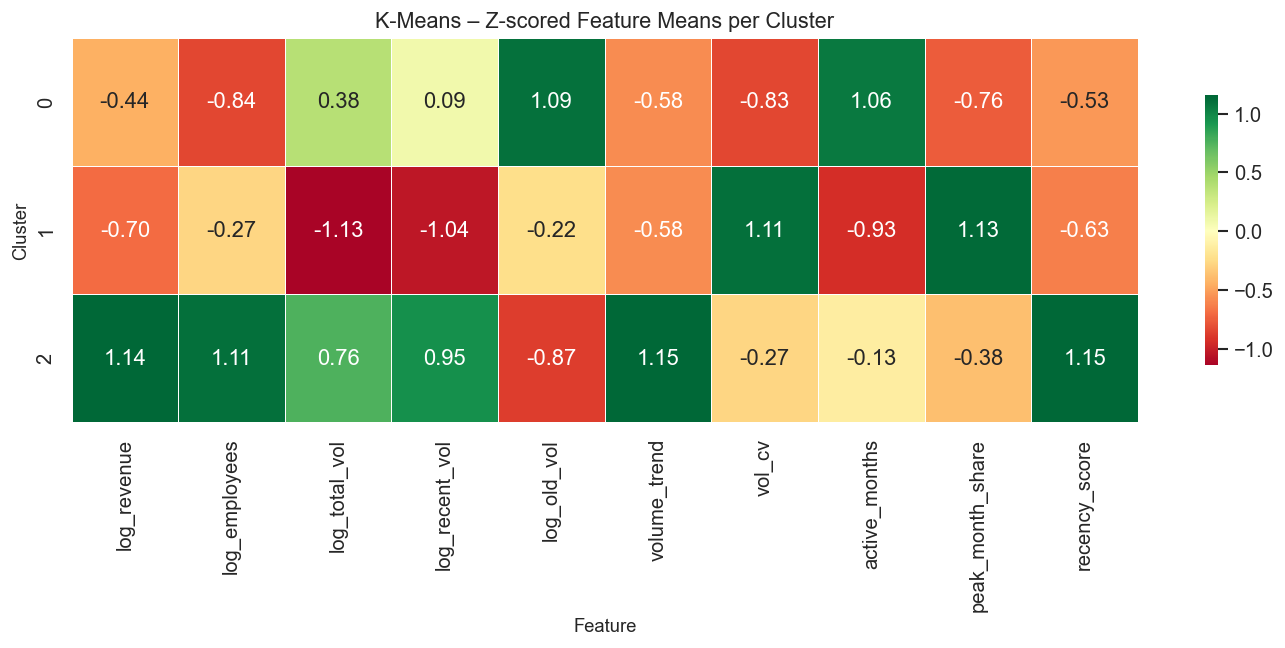

In [12]:
# Heatmap: Z-scored feature means per cluster
cluster_means_z = (
    df_clean.groupby('km_cluster')[FEATURE_COLS].mean()
    .apply(lambda col: (col - col.mean()) / col.std())
)

fig, ax = plt.subplots(figsize=(12, 1.2 * BEST_K + 2))
sns.heatmap(cluster_means_z, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7})
ax.set(title='K-Means – Z-scored Feature Means per Cluster',
       xlabel='Feature', ylabel='Cluster')
plt.tight_layout()
plt.show()

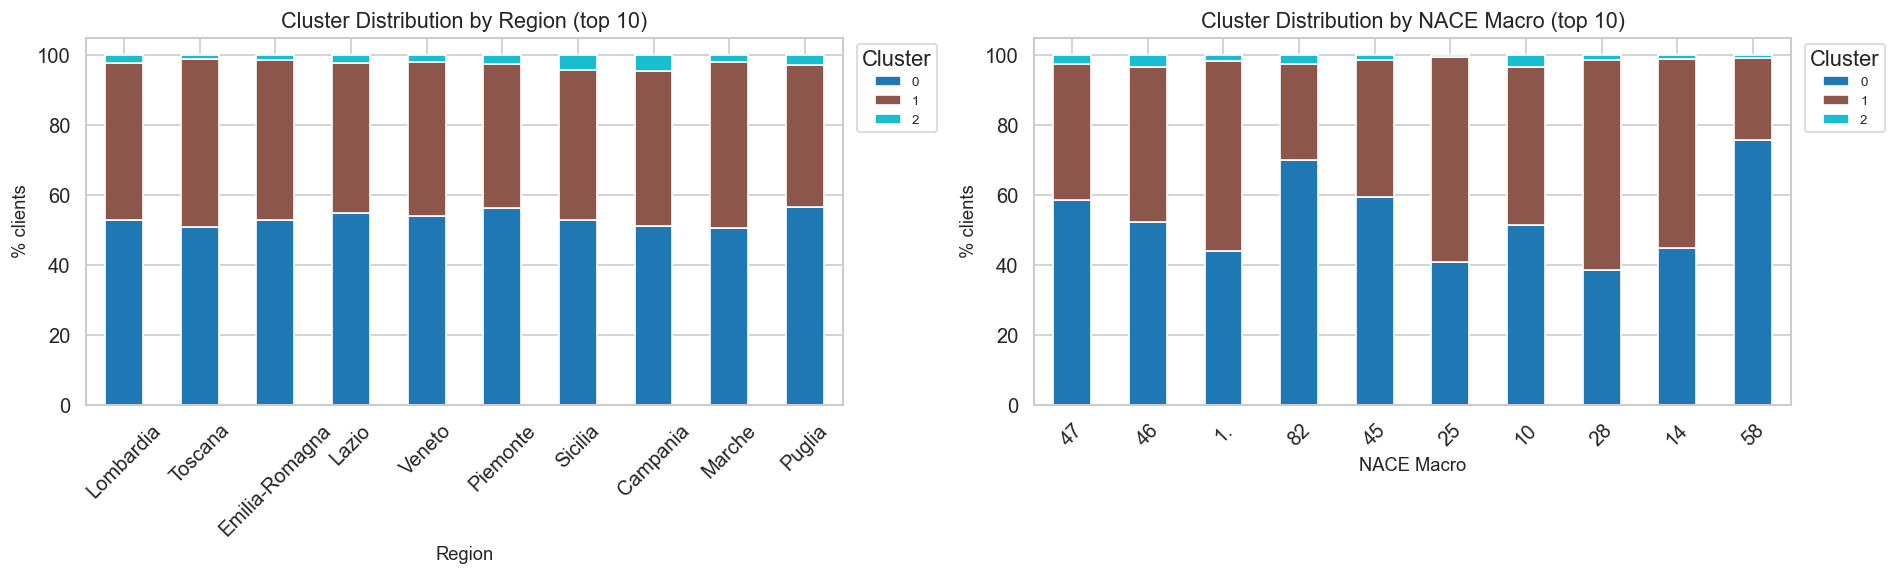

In [13]:
# Cluster distribution by Region and NACE macro
df_clean['NACE_macro'] = df_clean['NACE'].astype(str).str[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Region
reg_clust = pd.crosstab(df_clean['Region'], df_clean['km_cluster'],
                         normalize='index') * 100
top_regions = df_clean['Region'].value_counts().head(10).index
reg_clust.loc[top_regions].plot(kind='bar', stacked=True, ax=axes[0],
                                 colormap='tab10', edgecolor='white')
axes[0].set(title='Cluster Distribution by Region (top 10)',
            xlabel='Region', ylabel='% clients')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# NACE macro
nace_clust = pd.crosstab(df_clean['NACE_macro'], df_clean['km_cluster'],
                          normalize='index') * 100
top_nace = df_clean['NACE_macro'].value_counts().head(10).index
nace_clust.loc[top_nace].plot(kind='bar', stacked=True, ax=axes[1],
                               colormap='tab10', edgecolor='white')
axes[1].set(title='Cluster Distribution by NACE Macro (top 10)',
            xlabel='NACE Macro', ylabel='% clients')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. DBSCAN

DBSCAN does not require specifying K but needs two hyperparameters:  
- **`eps`** – neighbourhood radius  
- **`min_samples`** – minimum points to form a core point

We use the **k-distance plot** (k = `min_samples`) to identify the natural "knee" for `eps`.

### 5.1 eps search via k-distance plot

min_samples = 9


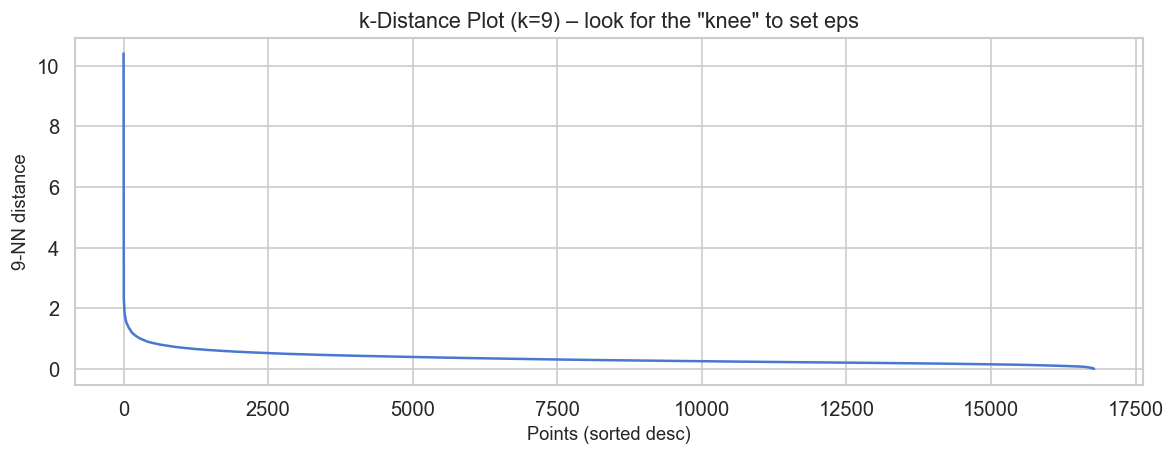

Suggested eps (knee) ≈ 10.4085  – adjust below if needed


In [14]:
MIN_SAMPLES = max(5, int(np.log(len(X_nd))))   # rule of thumb: ln(n)
print(f'min_samples = {MIN_SAMPLES}')

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES, algorithm='auto', n_jobs=-1)
nbrs.fit(X_nd)
distances, _ = nbrs.kneighbors(X_nd)
k_distances   = np.sort(distances[:, -1])[::-1]  # descending

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances, color=sns.color_palette('muted')[0], linewidth=1.5)
ax.set(title=f'k-Distance Plot (k={MIN_SAMPLES}) – look for the "knee" to set eps',
       xlabel='Points (sorted desc)', ylabel=f'{MIN_SAMPLES}-NN distance')
plt.tight_layout()
plt.show()

# Suggest eps at the knee using gradient change
grad = np.gradient(k_distances)
knee_idx = np.argmax(np.abs(np.gradient(grad)))  # inflection point
eps_suggested = float(k_distances[knee_idx])
print(f'Suggested eps (knee) ≈ {eps_suggested:.4f}  – adjust below if needed')

### 5.2 Grid search over (eps, min_samples)

In [15]:
# Define search space around the suggested eps
eps_values      = np.round(np.linspace(eps_suggested * 0.5, eps_suggested * 1.5, 8), 4)
min_samples_vals = [5, MIN_SAMPLES, MIN_SAMPLES * 2]

results = []
for eps_v in eps_values:
    for ms in min_samples_vals:
        db = DBSCAN(eps=eps_v, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(X_nd)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = int((labels == -1).sum())
        noise_pct  = n_noise / len(labels) * 100
        sil = None
        if n_clusters >= 2 and noise_pct < 50:
            mask_core = labels != -1
            if mask_core.sum() > 1:
                sil = silhouette_score(X_nd[mask_core], labels[mask_core],
                                       sample_size=5000, random_state=RANDOM_STATE)
        results.append(dict(eps=eps_v, min_samples=ms, n_clusters=n_clusters,
                            n_noise=n_noise, noise_pct=noise_pct, silhouette=sil))
        sil_str = f'{sil:.3f}' if sil is not None else 'N/A'
        print(f'eps={eps_v:.4f}  ms={ms:3d}  -> clusters={n_clusters:3d}  '
              f'noise={noise_pct:.1f}%  sil={sil_str}')

results_df = pd.DataFrame(results)
print('\n--- Grid results sorted by silhouette (core points only) ---')
print(results_df.sort_values('silhouette', ascending=False).head(10).to_string(index=False))

eps=5.2042  ms=  5  -> clusters=  1  noise=0.0%  sil=N/A
eps=5.2042  ms=  9  -> clusters=  1  noise=0.0%  sil=N/A
eps=5.2042  ms= 18  -> clusters=  1  noise=0.0%  sil=N/A
eps=6.6912  ms=  5  -> clusters=  1  noise=0.0%  sil=N/A
eps=6.6912  ms=  9  -> clusters=  1  noise=0.0%  sil=N/A
eps=6.6912  ms= 18  -> clusters=  1  noise=0.0%  sil=N/A
eps=8.1781  ms=  5  -> clusters=  1  noise=0.0%  sil=N/A
eps=8.1781  ms=  9  -> clusters=  1  noise=0.0%  sil=N/A
eps=8.1781  ms= 18  -> clusters=  1  noise=0.0%  sil=N/A
eps=9.6650  ms=  5  -> clusters=  1  noise=0.0%  sil=N/A
eps=9.6650  ms=  9  -> clusters=  1  noise=0.0%  sil=N/A
eps=9.6650  ms= 18  -> clusters=  1  noise=0.0%  sil=N/A
eps=11.1519  ms=  5  -> clusters=  1  noise=0.0%  sil=N/A
eps=11.1519  ms=  9  -> clusters=  1  noise=0.0%  sil=N/A
eps=11.1519  ms= 18  -> clusters=  1  noise=0.0%  sil=N/A
eps=12.6389  ms=  5  -> clusters=  1  noise=0.0%  sil=N/A
eps=12.6389  ms=  9  -> clusters=  1  noise=0.0%  sil=N/A
eps=12.6389  ms= 18  -> cl

### 5.3 Fit final DBSCAN

Choose `BEST_EPS` and `BEST_MS` from the grid results.  
**Override manually if a different combination makes more business sense.**

In [16]:
print('\n--- Full grid results ---')
print(results_df.sort_values(['n_clusters', 'noise_pct']).to_string(index=False))

# ── Strategy 1: good silhouette, bounded noise, reasonable cluster count ──
good = results_df[
    (results_df['noise_pct'] < 20) &
    (results_df['n_clusters'] >= 2) &
    (results_df['n_clusters'] <= 15) &
    results_df['silhouette'].notna()
].sort_values('silhouette', ascending=False)

# ── Strategy 2: relax noise threshold ──
if len(good) == 0:
    good = results_df[
        (results_df['n_clusters'] >= 2) &
        (results_df['n_clusters'] <= 15)
    ].sort_values('noise_pct')

# ── Strategy 3: any row with >= 2 clusters ──
if len(good) == 0:
    good = results_df[results_df['n_clusters'] >= 2].sort_values('noise_pct')

# ── Strategy 4: much wider eps sweep on the same X_nd ──
if len(good) == 0:
    print('WARNING: original grid found no valid config. Running wide eps sweep on X_nd...')
    # Sample a percentile range of pairwise distances to set a meaningful eps grid
    from sklearn.metrics import pairwise_distances_chunked
    sample_idx = np.random.default_rng(RANDOM_STATE).choice(
        len(X_nd), size=min(2000, len(X_nd)), replace=False
    )
    dists_sample = []
    for chunk in pairwise_distances_chunked(X_nd[sample_idx], n_jobs=-1):
        # upper-triangle values only
        dists_sample.append(chunk[np.triu(np.ones(chunk.shape, dtype=bool), k=1)])
    all_dists = np.concatenate(dists_sample)
    p5, p95 = np.percentile(all_dists, [5, 95])
    wide_eps = np.round(np.linspace(p5, p95 * 0.3, 15), 4)
    print(f'  Distance p5={p5:.4f}  p95={p95:.4f}  -> testing eps in [{wide_eps[0]:.4f}, {wide_eps[-1]:.4f}]')
    extra_results = []
    for eps_v in wide_eps:
        for ms in [3, 5, MIN_SAMPLES, MIN_SAMPLES * 2]:
            db_tmp  = DBSCAN(eps=eps_v, min_samples=ms, n_jobs=-1)
            lbl_tmp = db_tmp.fit_predict(X_nd)
            nc  = len(set(lbl_tmp)) - (1 if -1 in lbl_tmp else 0)
            np_ = int((lbl_tmp == -1).sum())
            npct = np_ / len(lbl_tmp) * 100
            sil_w = None
            if nc >= 2 and npct < 60:
                core_mask = lbl_tmp != -1
                if core_mask.sum() > 1:
                    sil_w = silhouette_score(X_nd[core_mask], lbl_tmp[core_mask],
                                             sample_size=5000, random_state=RANDOM_STATE)
            extra_results.append(dict(eps=eps_v, min_samples=ms, n_clusters=nc,
                                      n_noise=np_, noise_pct=npct, silhouette=sil_w))
    extra_df = pd.DataFrame(extra_results)
    print(extra_df.to_string(index=False))
    good = extra_df[extra_df['n_clusters'] >= 2].sort_values(
        ['noise_pct', 'n_clusters'], ascending=[True, False]
    )

# ── Strategy 5: fall back to 2D PCA space ──
if len(good) == 0:
    print('WARNING: X_nd failed entirely. Falling back to 2D PCA space (X_2d)...')
    from sklearn.metrics import pairwise_distances_chunked
    sample_idx = np.random.default_rng(RANDOM_STATE).choice(
        len(X_2d), size=min(2000, len(X_2d)), replace=False
    )
    dists_sample = []
    for chunk in pairwise_distances_chunked(X_2d[sample_idx], n_jobs=-1):
        dists_sample.append(chunk[np.triu(np.ones(chunk.shape, dtype=bool), k=1)])
    all_dists_2d = np.concatenate(dists_sample)
    p5_2d, p95_2d = np.percentile(all_dists_2d, [5, 95])
    wide_eps_2d = np.round(np.linspace(p5_2d, p95_2d * 0.4, 15), 4)
    fb_results = []
    for eps_v in wide_eps_2d:
        for ms in [3, 5, MIN_SAMPLES]:
            db_tmp  = DBSCAN(eps=eps_v, min_samples=ms, n_jobs=-1)
            lbl_tmp = db_tmp.fit_predict(X_2d)
            nc  = len(set(lbl_tmp)) - (1 if -1 in lbl_tmp else 0)
            np_ = int((lbl_tmp == -1).sum())
            npct = np_ / len(lbl_tmp) * 100
            fb_results.append(dict(eps=eps_v, min_samples=ms, n_clusters=nc,
                                   n_noise=np_, noise_pct=npct, silhouette=None))
    fb_df = pd.DataFrame(fb_results)
    good  = fb_df[fb_df['n_clusters'] >= 2].sort_values(
        ['noise_pct', 'n_clusters'], ascending=[True, False]
    )
    if len(good) > 0:
        # refit with X_2d from this point on
        X_nd = X_2d
        print('  Switched DBSCAN input space to X_2d.')
    print(fb_df.to_string(index=False))

if len(good) == 0:
    raise RuntimeError(
        'DBSCAN could not find >= 2 clusters across all parameter combinations\n'
        'and both X_nd and X_2d input spaces.\n'
        'Consider increasing DBSCAN_MAX_COMPONENTS or reviewing the feature set.'
    )

BEST_EPS = float(good.iloc[0]['eps'])
BEST_MS  = int(good.iloc[0]['min_samples'])
print(f'\nSelected: eps={BEST_EPS}  min_samples={BEST_MS}')
print(f'Expected: {int(good.iloc[0]["n_clusters"])} clusters, '
      f'{good.iloc[0]["noise_pct"]:.1f}% noise')

db_final  = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS, n_jobs=-1)
db_labels = db_final.fit_predict(X_nd)
df_clean['db_cluster'] = db_labels

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = int((db_labels == -1).sum())
print(f'\nFinal DBSCAN: {n_db_clusters} clusters, {n_noise} noise points '
      f'({n_noise/len(db_labels)*100:.1f}%)')
print(pd.Series(db_labels).value_counts().sort_index())



--- Full grid results ---
    eps  min_samples  n_clusters  n_noise  noise_pct silhouette
 6.6912            5           1        0   0.000000       None
 6.6912            9           1        0   0.000000       None
 6.6912           18           1        0   0.000000       None
 8.1781            5           1        0   0.000000       None
 8.1781            9           1        0   0.000000       None
 8.1781           18           1        0   0.000000       None
 9.6650            5           1        0   0.000000       None
 9.6650            9           1        0   0.000000       None
 9.6650           18           1        0   0.000000       None
11.1519            5           1        0   0.000000       None
11.1519            9           1        0   0.000000       None
11.1519           18           1        0   0.000000       None
12.6389            5           1        0   0.000000       None
12.6389            9           1        0   0.000000       None
12.6389      

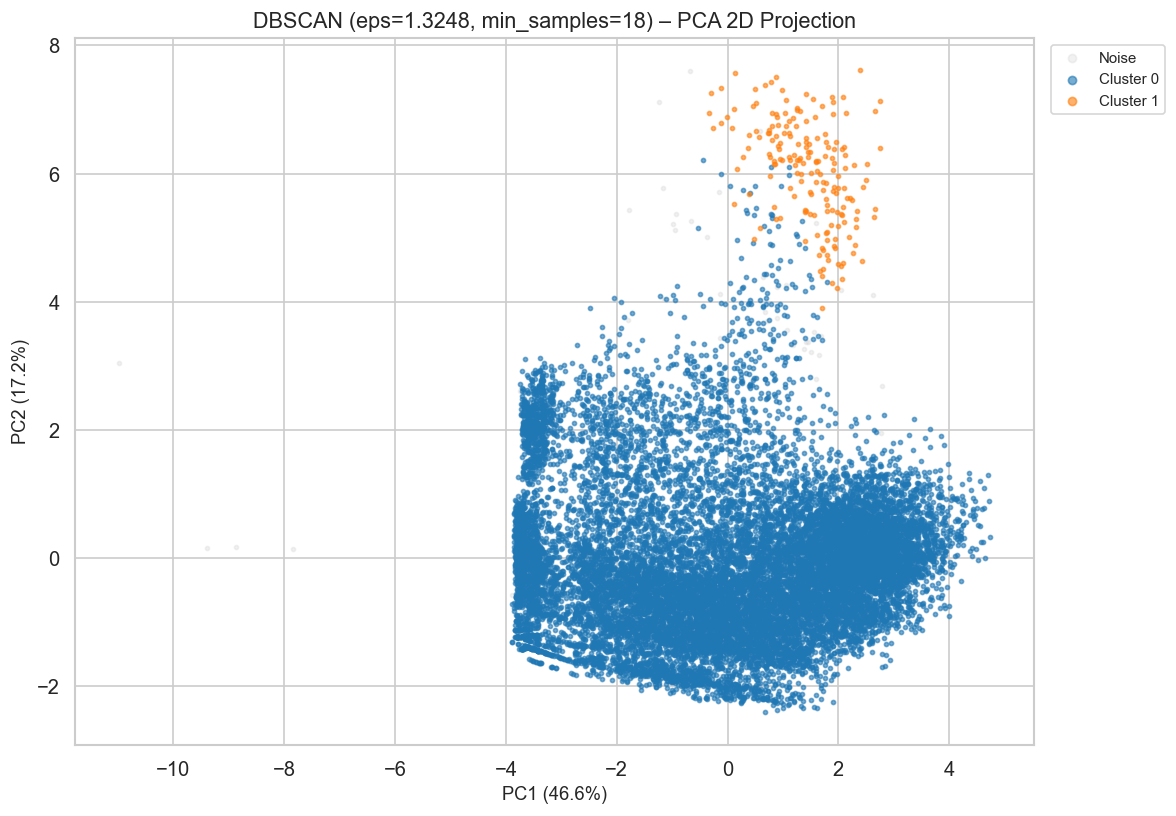

In [17]:
unique_labels = sorted(set(db_labels))
n_colors = len(unique_labels)
colors_db = sns.color_palette('tab10', max(n_colors, 10))

fig, ax = plt.subplots(figsize=(10, 7))
for label in unique_labels:
    mask = df_clean['db_cluster'] == label
    color = 'lightgrey' if label == -1 else colors_db[label % 10]
    lbl   = 'Noise' if label == -1 else f'Cluster {label}'
    alpha = 0.3 if label == -1 else 0.6
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=6, alpha=alpha, color=color, label=lbl)

ax.set(title=f'DBSCAN (eps={BEST_EPS}, min_samples={BEST_MS}) – PCA 2D Projection',
       xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=2, fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5.4 Cluster Profile

In [18]:
db_profile = (
    df_clean.groupby('db_cluster')[FEATURE_COLS + ['Revenue', 'Employees']]
    .agg(['mean', 'median'])
)
db_profile.columns = ['_'.join(c) for c in db_profile.columns]
db_profile['size'] = df_clean['db_cluster'].value_counts().sort_index()
db_profile['size_pct'] = (db_profile['size'] / len(df_clean) * 100).round(1)
db_profile

,log_revenue_mean,log_revenue_median,log_employees_mean,log_employees_median,log_total_vol_mean,log_total_vol_median,log_recent_vol_mean,log_recent_vol_median,log_old_vol_mean,log_old_vol_median,...,peak_month_share_mean,peak_month_share_median,recency_score_mean,recency_score_median,Revenue_mean,Revenue_median,Employees_mean,Employees_median,size,size_pct
db_cluster,,,,,,,,,,,,,,,,,,,,,
-1,7.425390,4.516503,2.659192,1.497866,8.659341,9.021417,7.399771,8.218382,0.950992,0.000000,...,0.597424,0.350245,0.707689,0.830334,7.448902e+06,4187.0,569.812500,3.5,48,0.3
0,10.818819,13.544236,2.075745,1.945910,6.534183,6.632002,3.335483,2.944439,4.416167,4.762174,...,0.346232,0.200000,0.266925,0.221191,4.303617e+06,762406.0,22.486769,6.0,16552,98.6
1,11.723333,14.340663,2.348613,2.197225,10.328622,10.110207,9.602010,9.338205,0.025028,0.000000,...,0.181154,0.141317,0.821220,0.910847,6.099233e+06,1690779.0,27.179348,8.0,184,1.1


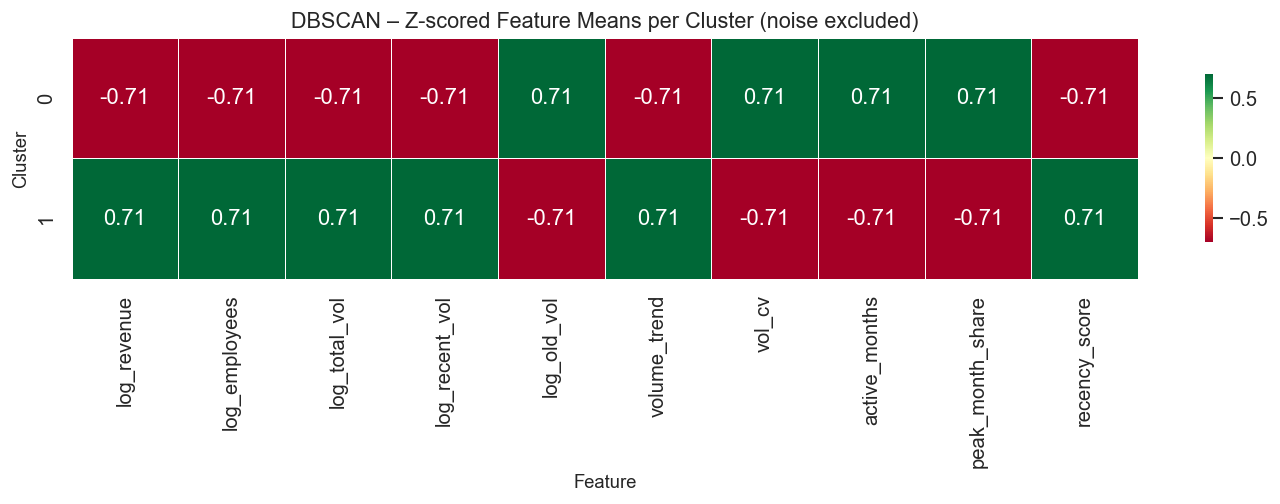

In [19]:
# Exclude noise cluster (-1) from heatmap
db_core = df_clean[df_clean['db_cluster'] != -1]
db_means_z = (
    db_core.groupby('db_cluster')[FEATURE_COLS].mean()
    .apply(lambda col: (col - col.mean()) / col.std())
)

fig, ax = plt.subplots(figsize=(12, 1.2 * n_db_clusters + 2))
sns.heatmap(db_means_z, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7})
ax.set(title='DBSCAN – Z-scored Feature Means per Cluster (noise excluded)',
       xlabel='Feature', ylabel='Cluster')
plt.tight_layout()
plt.show()

---
## 6. Cluster Comparison & Business Interpretation

### 6.1 Metrics summary

In [11]:
# Temporary test-only summary for quick inspection
comparison_rows = []

for k in [3, 5]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20,
                max_iter=500, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=min(5000, len(labels)), random_state=RANDOM_STATE)
    dbi = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    comparison_rows.append({
        'Algorithm': f'K-Means ({k})',
        'N Clusters': int(k),
        'Noise pts': 0,
        'Noise %': 0.0,
        'Silhouette ↑': round(sil, 3),
        'Davies-Bouldin ↓': round(dbi, 3),
        'Calinski-Harabasz ↑': round(ch, 1),
    })

for eps_v, ms, label in [(0.80, 9, 'DBSCAN (3)'), (0.60, 18, 'DBSCAN (5)')]:
    db = DBSCAN(eps=eps_v, min_samples=ms, n_jobs=-1)
    labels = db.fit_predict(X_nd)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    core_mask = labels != -1
    sil = None
    dbi = None
    ch = None
    if core_mask.sum() > 1 and n_clusters >= 2:
        sil = silhouette_score(X_scaled[core_mask], labels[core_mask],
                               sample_size=min(5000, core_mask.sum()), random_state=RANDOM_STATE)
        dbi = davies_bouldin_score(X_scaled[core_mask], labels[core_mask])
        ch = calinski_harabasz_score(X_scaled[core_mask], labels[core_mask])
    comparison_rows.append({
        'Algorithm': label,
        'N Clusters': int(n_clusters),
        'Noise pts': int(n_noise),
        'Noise %': round(n_noise / len(labels) * 100, 1),
        'Silhouette ↑': round(sil, 3) if sil is not None else np.nan,
        'Davies-Bouldin ↓': round(dbi, 3) if dbi is not None else np.nan,
        'Calinski-Harabasz ↑': round(ch, 1) if ch is not None else np.nan,
    })

summary = pd.DataFrame(comparison_rows)
print(summary.to_string(index=False))


  Algorithm  N Clusters  Noise pts  Noise %  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
K-Means (3)           3          0      0.0         0.337             1.032               6752.0
K-Means (5)           5          0      0.0         0.285             1.142               6556.2
 DBSCAN (3)           3        263      1.6         0.577             0.738                740.8
 DBSCAN (5)           5       1412      8.4        -0.010             0.893                181.4


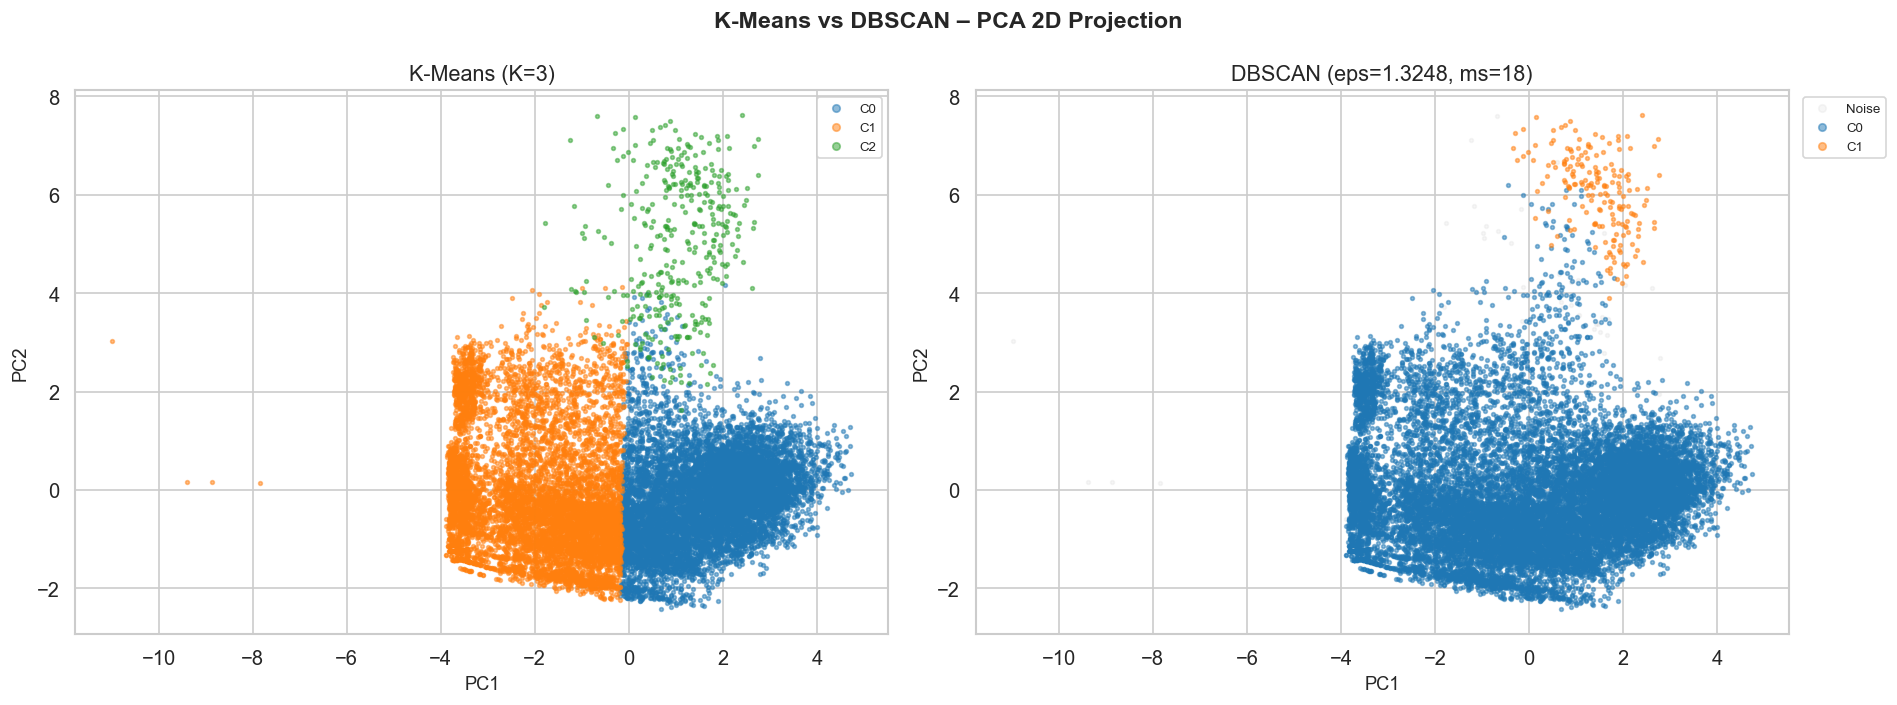

In [21]:
# Side-by-side scatter for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means vs DBSCAN – PCA 2D Projection', fontsize=14, fontweight='bold')

# K-Means
for c in range(BEST_K):
    m = df_clean['km_cluster'] == c
    axes[0].scatter(X_2d[m, 0], X_2d[m, 1],
                    s=5, alpha=0.5, color=palette[c], label=f'C{c}')
axes[0].set(title=f'K-Means (K={BEST_K})',
            xlabel='PC1', ylabel='PC2')
axes[0].legend(markerscale=2, fontsize=8)

# DBSCAN
for label in unique_labels:
    m = df_clean['db_cluster'] == label
    color = 'lightgrey' if label == -1 else colors_db[label % 10]
    lbl   = 'Noise' if label == -1 else f'C{label}'
    alpha = 0.2 if label == -1 else 0.5
    axes[1].scatter(X_2d[m, 0], X_2d[m, 1],
                    s=5, alpha=alpha, color=color, label=lbl)
axes[1].set(title=f'DBSCAN (eps={BEST_EPS}, ms={BEST_MS})',
            xlabel='PC1', ylabel='PC2')
axes[1].legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [22]:
# Cross-tabulation: how do K-Means clusters map to DBSCAN clusters?
ct = pd.crosstab(df_clean['km_cluster'], df_clean['db_cluster'],
                 rownames=['K-Means'], colnames=['DBSCAN'])
print('Cross-tabulation (K-Means rows x DBSCAN cols):')
print(ct)

Cross-tabulation (K-Means rows x DBSCAN cols):
DBSCAN   -1     0    1
K-Means               
0         6  8830    0
1        10  7572    0
2        32   150  184


In [23]:
# --- Business interpretation labels (K-Means) ---
# Based on the radar / heatmap analysis above:
# adjust the dict below to reflect what you observe in your run.

km_cluster_means = df_clean.groupby('km_cluster')[
    ['log_revenue', 'log_total_vol', 'log_recent_vol',
     'active_months', 'recency_score', 'volume_trend']
].mean()

print('K-Means cluster mean feature values (use these to write business labels):')
print(km_cluster_means.round(3))

# Example auto-labelling heuristics (adapt as needed)
labels_map = {}
for c, row in km_cluster_means.iterrows():
    if row['log_revenue'] > km_cluster_means['log_revenue'].median() and \
       row['log_total_vol'] > km_cluster_means['log_total_vol'].median():
        label = 'High-Value Active'
    elif row['active_months'] < km_cluster_means['active_months'].quantile(0.33):
        label = 'Occasional / At-Risk'
    elif row['recency_score'] > 0.5 and row['volume_trend'] > 1:
        label = 'Growing / Recent'
    elif row['log_revenue'] < km_cluster_means['log_revenue'].median():
        label = 'Small / Low-Activity'
    else:
        label = 'Stable Mid-Tier'
    labels_map[c] = label
    print(f'  Cluster {c} -> {label}')

df_clean['km_label'] = df_clean['km_cluster'].map(labels_map)
print('\nLabel distribution:')
print(df_clean['km_label'].value_counts())

K-Means cluster mean feature values (use these to write business labels):
            log_revenue  log_total_vol  log_recent_vol  active_months  \
km_cluster                                                              
0                10.845          8.470           5.382         28.806   
1                10.765          4.240           0.864          4.539   
2                11.329          9.525           8.822         14.361   

            recency_score  volume_trend  
km_cluster                               
0                   0.277        29.627  
1                   0.244        23.513  
2                   0.842      4557.707  
  Cluster 0 -> Stable Mid-Tier
  Cluster 1 -> Occasional / At-Risk
  Cluster 2 -> High-Value Active

Label distribution:
km_label
Stable Mid-Tier         8836
Occasional / At-Risk    7582
High-Value Active        366
Name: count, dtype: int64


In [24]:
# Save results
output_path = os.path.join(BASE_DIR, 'source', 'dataset_clustered.csv')
cols_to_save = list(df.columns) + ['km_cluster', 'km_label', 'db_cluster']
df_clean[cols_to_save].to_csv(output_path, index=False)
print(f'Clustered dataset saved to: {output_path}')
print(f'Shape: {df_clean[cols_to_save].shape}')

Clustered dataset saved to: C:\Users\esaba\Desktop\Git hub projects\CapstoneProject-Logistic-S.p.a\source\dataset_clustered.csv
Shape: (16784, 46)
